In this project we choose set out to determine the best neighborhood in Pittsburgh. A factor we both agreed could be used to determine was saftey as saftey is of the upmost priority when chooisng somewhere to live.

We decided to use overall neighborhood saftey as our final metric. The three data sets we choose represnet a neighborhoods saftey.

1. crimes committed since 2024 in Allengheny county. Neighborhoods with less crime are gennarlly safer.
2. Playgorunds in Allengheny county. Reprensents saftey for children and raising a family
3. Fires in Allengheny county since 2013. Represents saftey and qualtiy of housing.

The final metric combines normalized crime, fire, and playground counts into a single score where crime and fires increase the value, while playgrounds decrease it. Lower values indicate safer neighborhoods because they reflect less crime and fire activity and more playgrounds. 

List Of Neighboorhoods

In [18]:
#geting the name of each neighboorhood and sorting alpahbetically
import pandas as pd
neighborhoods = pd.read_csv("Neighboorhoods.csv")

neighborhood_list = sorted(
    neighborhoods["hood"].dropna().str.strip().unique()
)

print(neighborhood_list)

['Allegheny Center', 'Allegheny West', 'Allentown', 'Arlington', 'Arlington Heights', 'Banksville', 'Bedford Dwellings', 'Beechview', 'Beltzhoover', 'Bloomfield', 'Bluff', 'Bon Air', 'Brighton Heights', 'Brookline', 'California-Kirkbride', 'Carrick', 'Central Business District', 'Central Lawrenceville', 'Central Northside', 'Central Oakland', 'Chartiers City', 'Chateau', 'Crafton Heights', 'Crawford-Roberts', 'Duquesne Heights', 'East Allegheny', 'East Carnegie', 'East Hills', 'East Liberty', 'Elliott', 'Esplen', 'Fairywood', 'Fineview', 'Friendship', 'Garfield', 'Glen Hazel', 'Greenfield', 'Hays', 'Hazelwood', 'Highland Park', 'Homewood North', 'Homewood South', 'Homewood West', 'Knoxville', 'Larimer', 'Lincoln Place', 'Lincoln-Lemington-Belmar', 'Lower Lawrenceville', 'Manchester', 'Marshall-Shadeland', 'Middle Hill', 'Morningside', 'Mount Washington', 'Mt. Oliver', 'New Homestead', 'North Oakland', 'North Shore', 'Northview Heights', 'Oakwood', 'Overbrook', 'Perry North', 'Perry Sou

Number of crimes commited in each neighboorhood since 2024

In [19]:
import pandas as pd
from io import StringIO

# Load  crime CSV
with open("CrimeRate.csv", encoding="latin-1") as f:
    content = f.read().replace('\r', '')  # remove carriage returns

lines = content.split('\n')
cleaned = []

# Clean up un-unifrom CSV lines
for line in lines:
    if line:
        line = line.strip()
        
        # remove extra quotes and trailing commas if present
        if line.startswith('"') and line.endswith('",,,'):
            line = line[1:-4]
        elif line.startswith('"') and line.endswith('",'):
            line = line[1:-2]
        
        cleaned.append(line)

# Read clean data into data frame
crimes = pd.read_csv(
    StringIO('\n'.join(cleaned)),
    on_bad_lines='skip',
    low_memory=False
)

#column names
crimes.columns = crimes.columns.str.strip()


crimes["Neighborhood"] = crimes["Neighborhood"].astype(str).str.strip()

# LOAD neighborhood LIST
neighborhoods = pd.read_csv("Neighboorhoods.csv")
neighborhoods.columns = neighborhoods.columns.str.strip()

neighborhood_list = sorted(neighborhoods["hood"].dropna().astype(str).str.strip().unique()
)

# count crimes per neighborhood
crime_counts = []

crime_counts = []

for hood in neighborhood_list:
    count = (crimes["Neighborhood"] == hood).sum()
    crime_counts.append((hood, count))

# creating final data frame
crime_count_list = pd.DataFrame(crime_counts,columns=["Neighborhood", "Crime_Count"])

print(crime_count_list)

           Neighborhood  Crime_Count
0      Allegheny Center          683
1        Allegheny West          184
2             Allentown         1530
3             Arlington          436
4     Arlington Heights          157
..                  ...          ...
85  Upper Lawrenceville          343
86             West End          374
87         West Oakland          453
88             Westwood          268
89              Windgap          162

[90 rows x 2 columns]


Ten neighborhoods with least crime

In [24]:
top_10_safest = crime_count_list.sort_values(by="Crime_Count", ascending=True).head(10)

print("\nTop 10 Neighborhoods with Least Crime:")
print(top_10_safest)


Top 10 Neighborhoods with Least Crime:
             Neighborhood  Crime_Count
53             Mt. Oliver            0
20         Chartiers City            5
77              St. Clair           12
66              Ridgemont           40
54          New Homestead           61
81         Swisshelm Park           76
26          East Carnegie           80
80            Summer Hill           94
74  Spring Hill-City View          103
30                 Esplen          104


Amount of playgrounds in each neighboorhood

In [20]:
#Downloding playgound csv
playgrounds = pd.read_csv("Playground Equipment.csv", low_memory=False)
playgrounds["neighborhood"] = playgrounds["neighborhood"].str.strip()

#counting playgrounds
playground_counts = []
for hood in neighborhood_list:
    count = (playgrounds["neighborhood"] == hood).sum()
    playground_counts.append((hood, count))

#Creating table
playgrounds_counts_list = pd.DataFrame(playground_counts,columns=["Neighborhood", "Playground_Count"])

print("5 neighboorhoods with most playgrounds.")
print("")
print(playgrounds_counts_list.sort_values("Playground_Count", ascending=False).head(5))


5 neighboorhoods with most playgrounds.

           Neighborhood  Playground_Count
76  Squirrel Hill South                32
28         East Liberty                26
7             Beechview                21
0      Allegheny Center                15
72    South Side Slopes                14


Fires per neighborhood since 2013

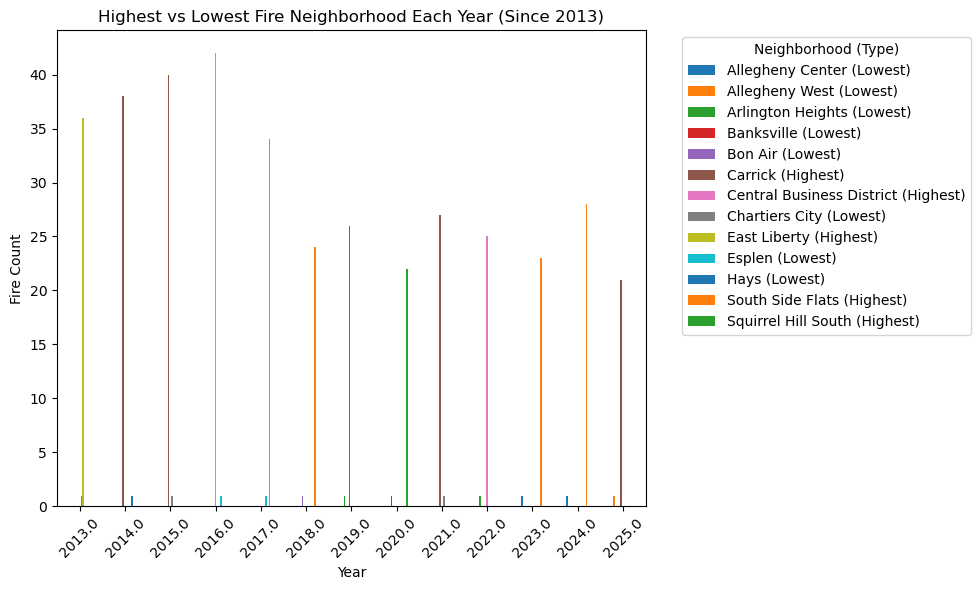

In [21]:
#Finding fires per neighborhood
fires = pd.read_csv("Fires.csv", low_memory=False)
fires["neighborhood"] = fires["neighborhood"].str.strip()

fire_counts = []
for hood in neighborhood_list:
    count = (fires["neighborhood"] == hood).sum()
    fire_counts.append((hood, count))

fires_counts_list = pd.DataFrame(
    fire_counts,
    columns=["Neighborhood", "Fire_Count"]
)

#Creating bar graph that shows neighborhoods with most and least fires since 2013 each year
import matplotlib.pyplot as plt

fires = pd.read_csv("Fires.csv", low_memory=False)

fires["neighborhood"] = fires["neighborhood"].str.strip()

fires["alarm_time"] = pd.to_datetime(fires["alarm_time"], errors="coerce")
fires["year"] = fires["alarm_time"].dt.year

fires = fires[fires["year"] >= 2013]

# count fires per year per neighborhood and finding highest and lowest
fires_per_year = (
    fires.groupby(["year", "neighborhood"]).size().reset_index(name="Fire_Count")
)


highest_each_year = fires_per_year.loc[fires_per_year.groupby("year")["Fire_Count"].idxmax()].copy()
lowest_each_year = fires_per_year.loc[fires_per_year.groupby("year")["Fire_Count"].idxmin()].copy()

#Creating labels
highest_each_year["Type"] = "Highest"
lowest_each_year["Type"] = "Lowest"

plot_df = pd.concat([highest_each_year, lowest_each_year])

plot_df["Label"] = plot_df["neighborhood"] + " (" + plot_df["Type"] + ")"

#labels appear on legend
pivot = plot_df.pivot(index="year", columns="Label", values="Fire_Count")

# ploting
pivot.plot(kind="bar", figsize=(10,6))

plt.title("Highest vs Lowest Fire Neighborhood Each Year (Since 2013)")
plt.xlabel("Year")
plt.ylabel("Fire Count")
plt.xticks(rotation=45)
plt.legend(title="Neighborhood (Type)", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()


Creating a final metric

In [22]:
#merging all three metrics into a single data frame
merged = crime_count_list.merge(fires_counts_list, on="Neighborhood")
merged = merged.merge(playgrounds_counts_list, on="Neighborhood")

#normalizing metrics so that all three hold same weight
merged["Crime_Normalized"] = merged["Crime_Count"] / merged["Crime_Count"].max()
merged["Fire_Normalized"] = merged["Fire_Count"] / merged["Fire_Count"].max()
merged["Play_Normalized"] = merged["Playground_Count"] / merged["Playground_Count"].max()

#calculating final metric
merged["Metric"] = (merged["Crime_Normalized"] +2 * merged["Fire_Normalized"] -merged["Play_Normalized"])

print(merged.sort_values("Metric").head())

        Neighborhood  Crime_Count  Fire_Count  Playground_Count  \
65     Regent Square          107           9                 9   
81    Swisshelm Park           76          17                 6   
58           Oakwood          122          13                 4   
54     New Homestead           61          22                 5   
0   Allegheny Center          683          63                15   

    Crime_Normalized  Fire_Normalized  Play_Normalized    Metric  
65          0.011717         0.027439          0.28125 -0.214655  
81          0.008322         0.051829          0.18750 -0.075519  
58          0.013360         0.039634          0.12500 -0.032372  
54          0.006680         0.067073          0.15625 -0.015424  
0           0.074792         0.192073          0.46875 -0.009812  


5 safets neighboorhoods

In [23]:
for _, row in merged.sort_values("Metric").head(5).iterrows():
    print(row["Neighborhood"], "-", round(row["Metric"], 4))

Regent Square - -0.2147
Swisshelm Park - -0.0755
Oakwood - -0.0324
New Homestead - -0.0154
Allegheny Center - -0.0098


We found that the best neighboorhood based on our metric was by far Regent Square with a saftey score of -0.2147, the next closest being Swisshelm Park with a score of -0.0755.

Darrin- Taking a data driven approahc we found that Regent Sqaure was the best neighborhood in the Pittsburgh area this was found by comibing our three idvidual metric of crimes, playgrounds, and fires to compile an overall saftye score. 

Me personally I was neither suprised nor expected Regent Sqaure to be the winner as im not from the Pittsburgh area, 
but from what ive reseached after doing this project it seems like a desirable place to live. 

Levar - The data-driven approach defines "best neighborhood" by best safety score — it's objective and numeric, with no room for personal preference. A personal favorite, on the other hand, factors in things like walkability, local restaurants, the feel of the community, proximity to friends, or even just familiarity.

Regent Square coming out on top was a bit surprising at first. It's a small, quiet residential neighborhood on the eastern edge of Pittsburgh that doesn't get much buzz compared to places like Lawrenceville or Shadyside. But thinking about it more, that quietness is probably exactly why it ranks so well — fewer people, less foot traffic, and a tight-knit community likely all contribute to lower crime. It's a good reminder that the neighborhoods that dominate "best of Pittsburgh" lists aren't always the safest ones — popularity and safety don't always go hand in hand.